In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

print("SHAP version:", shap.__version__)


SHAP version: 0.51.0


Load Model, Scaler & Data

In [2]:
# Load saved artifacts
best_xgb    = joblib.load('../models/xgboost_best_model.pkl')
scaler      = joblib.load('../models/scaler.pkl')
feature_names = joblib.load('../models/feature_names.pkl')

# Load processed data
df = pd.read_csv('../data/processed_churn.csv')
X  = df.drop('Churn', axis=1)
y  = df['Churn']

# Scale (same transform used during training)
X_sc = scaler.transform(X)
X_sc_df = pd.DataFrame(X_sc, columns=feature_names)

print("Data loaded. Shape:", X_sc_df.shape)


Data loaded. Shape: (7043, 47)


Build SHAP Explainer

In [3]:
# TreeExplainer is optimised for XGBoost — fast and exact
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_sc_df)

print("SHAP values shape:", shap_values.shape)
print("Expected value (base rate):", round(explainer.expected_value, 4))


SHAP values shape: (7043, 47)
Expected value (base rate): -1.0345


Global Feature Importance: Summary Bar Plot

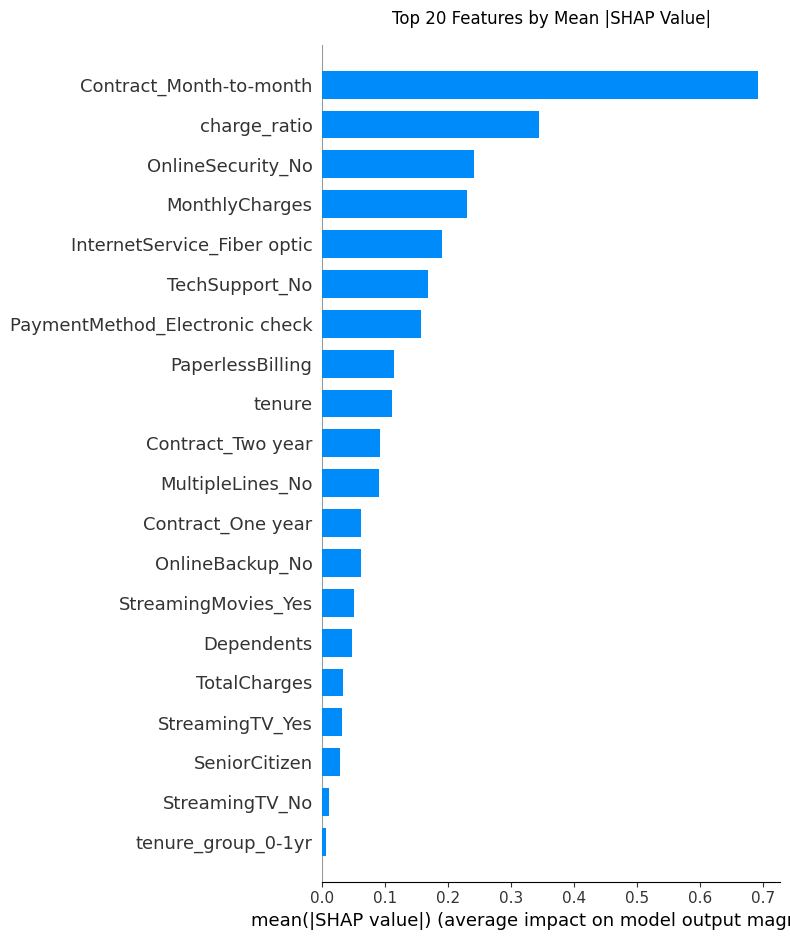

Saved: shap_bar_importance.png


In [4]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_sc_df,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("Top 20 Features by Mean |SHAP Value|", pad=15)
plt.tight_layout()
plt.savefig('../data/shap_bar_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_bar_importance.png")


SHAP Beeswarm Plot (Direction + Magnitude)

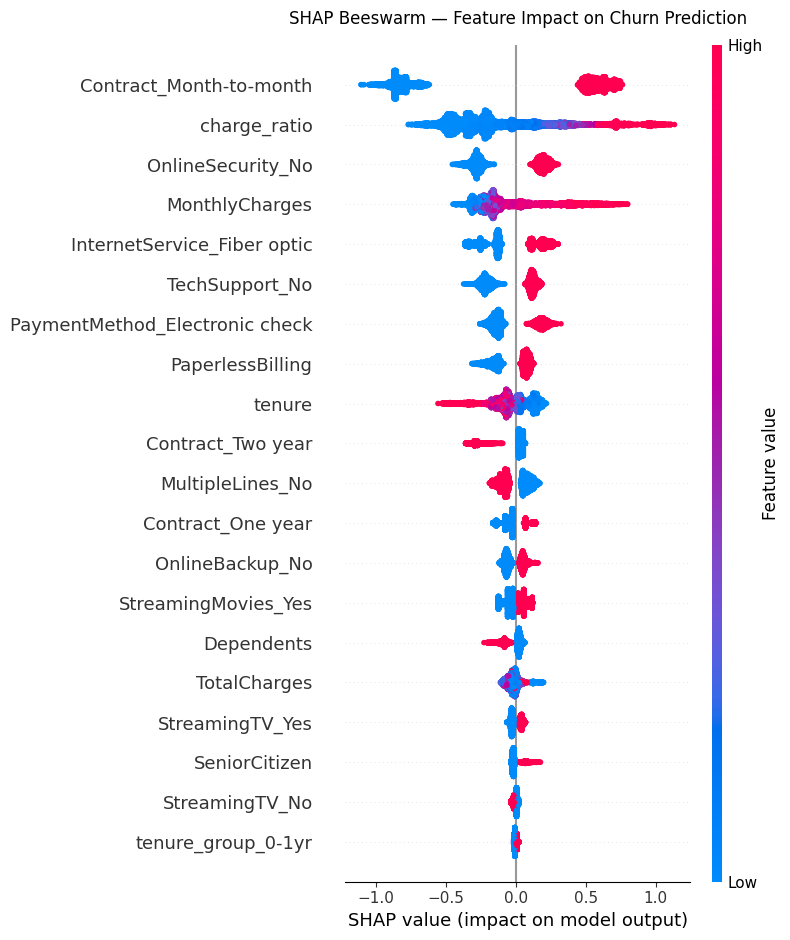

Saved: shap_beeswarm.png


In [5]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_sc_df,
    max_display=20,
    show=False
)
plt.title("SHAP Beeswarm — Feature Impact on Churn Prediction", pad=15)
plt.tight_layout()
plt.savefig('../data/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_beeswarm.png")


Dependence Plot: Contract Type vs Churn

Using column: Contract_Month-to-month


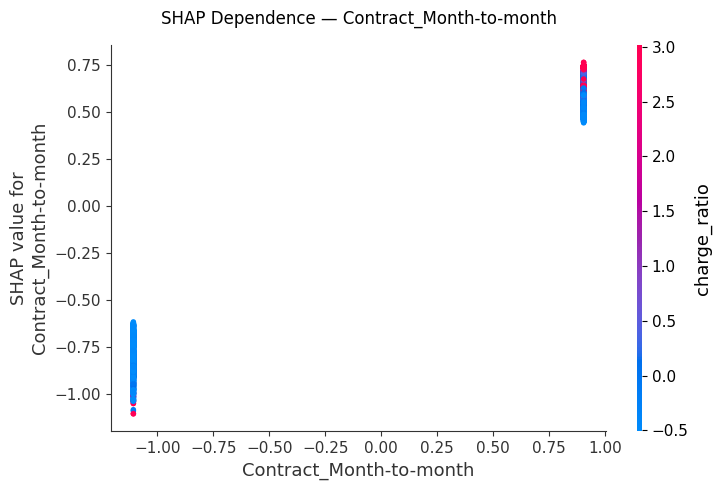

In [6]:
# Find the contract column (one-hot encoded)
contract_col = [c for c in feature_names if 'Contract_Month' in c][0]
print("Using column:", contract_col)

shap.dependence_plot(
    contract_col,
    shap_values,
    X_sc_df,
    show=False
)
plt.title(f"SHAP Dependence — {contract_col}", pad=15)
plt.tight_layout()
plt.savefig('../data/shap_dependence_contract.png', dpi=150, bbox_inches='tight')
plt.show()


Dependence Plot: Tenure vs Churn

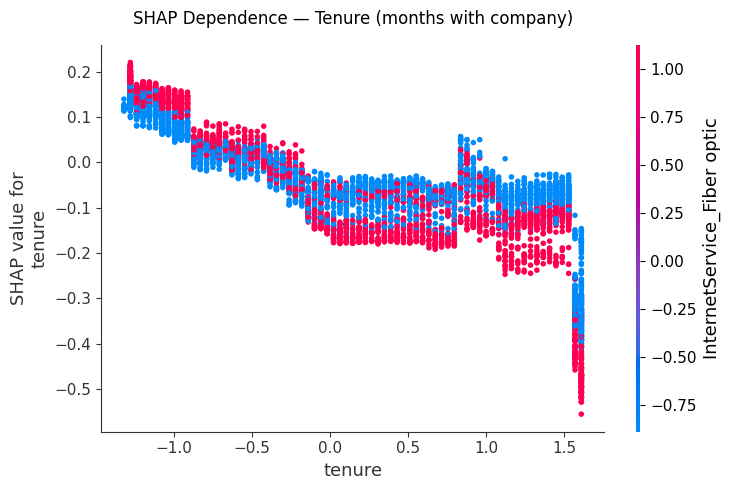

In [7]:
shap.dependence_plot(
    'tenure',
    shap_values,
    X_sc_df,
    show=False
)
plt.title("SHAP Dependence — Tenure (months with company)", pad=15)
plt.tight_layout()
plt.savefig('../data/shap_dependence_tenure.png', dpi=150, bbox_inches='tight')
plt.show()


Waterfall Plot: Single High-Risk Customer

Highest churn probability customer: index 2208
Predicted churn probability: 0.913
Actual label: Churn


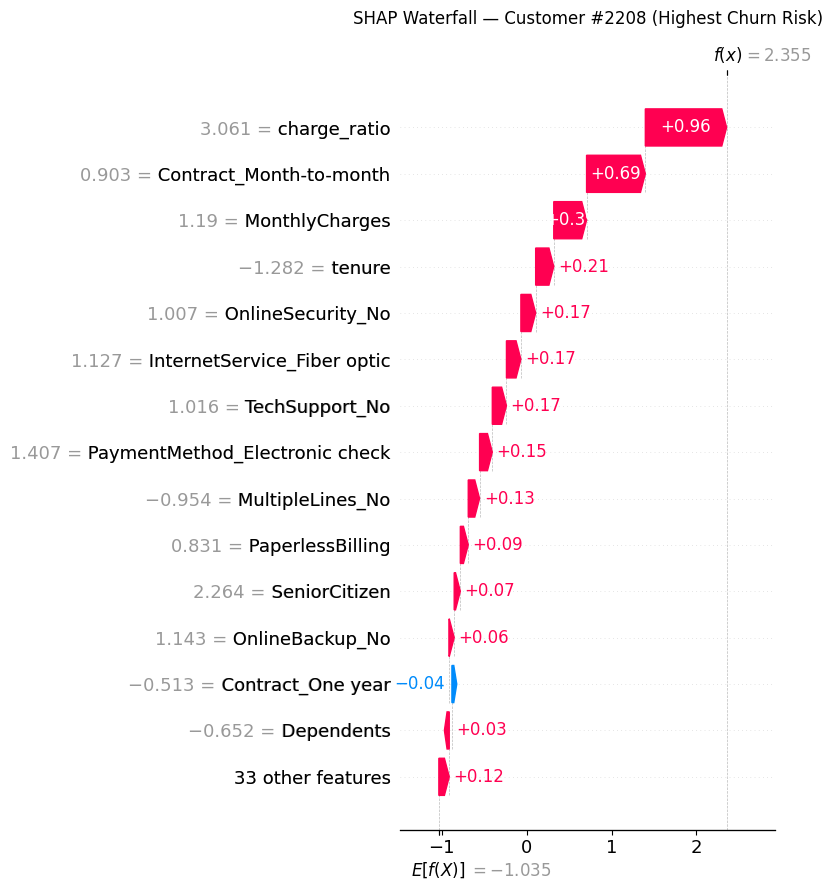

In [8]:
# Find the highest-risk customer in the dataset
churn_probs = best_xgb.predict_proba(X_sc_df)[:, 1]
highest_risk_idx = churn_probs.argmax()
print(f"Highest churn probability customer: index {highest_risk_idx}")
print(f"Predicted churn probability: {churn_probs[highest_risk_idx]:.3f}")
print(f"Actual label: {'Churn' if y.iloc[highest_risk_idx] == 1 else 'No Churn'}")

# Waterfall plot for this customer
shap.plots.waterfall(
    shap.Explanation(
        values      = shap_values[highest_risk_idx],
        base_values = explainer.expected_value,
        data        = X_sc_df.iloc[highest_risk_idx],
        feature_names = feature_names
    ),
    max_display=15,
    show=False
)
plt.title(f"SHAP Waterfall — Customer #{highest_risk_idx} (Highest Churn Risk)", pad=15)
plt.tight_layout()
plt.savefig('../data/shap_waterfall_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()


Waterfall Plot: Single Low-Risk Customer

Lowest churn probability customer: index 1843
Predicted churn probability: 0.009
Actual label: No Churn


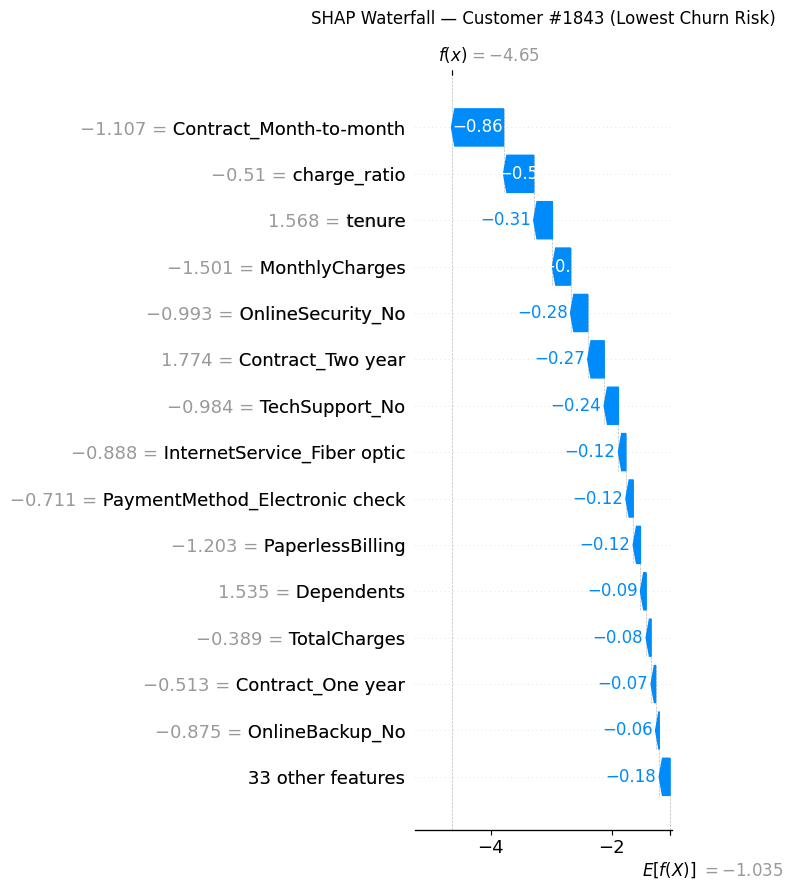

In [9]:
lowest_risk_idx = churn_probs.argmin()
print(f"Lowest churn probability customer: index {lowest_risk_idx}")
print(f"Predicted churn probability: {churn_probs[lowest_risk_idx]:.3f}")
print(f"Actual label: {'Churn' if y.iloc[lowest_risk_idx] == 1 else 'No Churn'}")

shap.plots.waterfall(
    shap.Explanation(
        values      = shap_values[lowest_risk_idx],
        base_values = explainer.expected_value,
        data        = X_sc_df.iloc[lowest_risk_idx],
        feature_names = feature_names
    ),
    max_display=15,
    show=False
)
plt.title(f"SHAP Waterfall — Customer #{lowest_risk_idx} (Lowest Churn Risk)", pad=15)
plt.tight_layout()
plt.savefig('../data/shap_waterfall_low_risk.png', dpi=150, bbox_inches='tight')
plt.show()


Top 10 Features Table

In [10]:
# Extract mean absolute SHAP values as a clean table
shap_importance = pd.DataFrame({
    'Feature':    feature_names,
    'Mean_SHAP':  np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)

shap_importance.index += 1   # start rank at 1
print("Top 10 Most Important Features (by Mean |SHAP|):\n")
print(shap_importance.head(10).to_string())

shap_importance.to_csv('../data/shap_feature_importance.csv', index=True)
print("\nSaved: shap_feature_importance.csv")


Top 10 Most Important Features (by Mean |SHAP|):

                           Feature  Mean_SHAP
1          Contract_Month-to-month   0.691887
2                     charge_ratio   0.344245
3                OnlineSecurity_No   0.240404
4                   MonthlyCharges   0.229264
5      InternetService_Fiber optic   0.190246
6                   TechSupport_No   0.167754
7   PaymentMethod_Electronic check   0.156923
8                 PaperlessBilling   0.113224
9                           tenure   0.110817
10               Contract_Two year   0.091209

Saved: shap_feature_importance.csv


## SHAP Analysis Summary

### Setup
- SHAP version: **0.51.0**
- Dataset shape: **(7,043 × 47 features)**
- SHAP values shape: **(7,043 × 47)** — one SHAP value per customer per feature
- Base rate (expected value): **-1.0345** (log-odds scale — corresponds to ~26.5% average churn)
- Contract column used: **`Contract_Month-to-month`**

### What is SHAP?
SHAP (SHapley Additive exPlanations) assigns each feature a contribution score
for each individual prediction. Unlike feature importances from tree models,
SHAP values are **directional** (positive = pushes toward churn, negative = away)
and **additive** (all SHAP values + base value = predicted log-odds for that customer).

---

### Top 10 Features by Churn Impact (Mean |SHAP Value|)

| Rank | Feature | Mean \|SHAP\| | Direction & Business Meaning |
|---|---|---|---|
| 1 | `Contract_Month-to-month` | **0.6919** | High value → strongly pushes toward churn. No long-term commitment = highest risk |
| 2 | `charge_ratio` | **0.3442** | High charge ratio (recent price increase) → strong churn trigger |
| 3 | `OnlineSecurity_No` | **0.2404** | No security add-on → significantly raises churn risk |
| 4 | `MonthlyCharges` | **0.2293** | Higher monthly bill → increases churn probability |
| 5 | `InternetService_Fiber optic` | **0.1902** | Fiber optic customers churn more (competitive market) |
| 6 | `TechSupport_No` | **0.1678** | No tech support → customer frustration → churn |
| 7 | `PaymentMethod_Electronic check` | **0.1569** | Least committed payment method → higher churn signal |
| 8 | `PaperlessBilling` | **0.1132** | Paperless billing customers churn more |
| 9 | `tenure` | **0.1108** | Low tenure → very high churn risk (non-linear) |
| 10 | `Contract_Two year` | **0.0912** | Two-year contract → strongly reduces churn risk |

---

### Individual Customer Findings

**Highest-risk customer (index 2208):**
- Predicted churn probability: **0.913** (91.3%)
- Actual label: **Churn** (correctly identified)
- Key drivers: Month-to-month contract, high charge_ratio, no OnlineSecurity, no TechSupport

**Lowest-risk customer (index 1843):**
- Predicted churn probability: **0.009** (0.9%)
- Actual label: **No Churn** (correctly identified)
- Key protectors: Two-year contract, long tenure, low monthly charges, has add-on services

---

### Key Business Insights from SHAP

**1. Contract Type is the single strongest predictor (SHAP = 0.69):**
- Month-to-month customers are dramatically more likely to churn
- Two-year contracts strongly protect against churn (rank 10, SHAP = 0.09 protective)
- → **Retention strategy: incentivise contract upgrades at the 6-month tenure mark**

**2. charge_ratio is the #2 driver — a surprise vs EDA (SHAP = 0.34):**
- This engineered feature (monthly charges / avg charge over lifetime) captures price shock
- Customers experiencing a recent price increase churn significantly more
- → **Proactively reach out to customers whose charge_ratio spikes above threshold**

**3. Service add-ons are strong retention tools:**
- Customers without OnlineSecurity (rank 3, SHAP = 0.24) and TechSupport (rank 6, SHAP = 0.17) churn significantly more
- Each add-on reduces churn probability — engagement = stickiness
- → **Cross-sell add-ons during onboarding to raise service_score**

**4. Fiber optic paradox (SHAP = 0.19):**
- Fiber customers pay more but churn more — likely due to competitive alternatives
- → **Proactive value communication and quality assurance for fiber customers**

**5. Tenure follows a sharp non-linear curve (SHAP = 0.11):**
- New customers (0–12 months) have the highest churn risk
- Risk drops sharply after 24 months
- → **Year 1 onboarding experience is the most critical retention window**

---

### Explainability Value for Business
These SHAP insights allow the business to:
1. **Segment customers** by risk profile and trigger personalised interventions
2. **Explain individual predictions** to customer success teams
   - e.g., *"Customer #2208 is flagged because: month-to-month contract (+highest weight),
     high charge_ratio (+second highest), no OnlineSecurity, no TechSupport"*
3. **Prioritise retention budget** on highest-impact levers:
   `Contract upgrade > charge_ratio monitoring > add-on cross-sell > fiber quality`
4. **Validate the model** — top SHAP features align with domain knowledge and EDA findings,
   building stakeholder confidence in the model's decisions